## 학습 관련 기술들

### 매개변수 갱신
* 최적의 매개변수 값을 찾는 단서로 매개변수의 기울기(미분)을 이용
* 지금까진 확률적 경사 하강법(SGD)를 통해 구함

#### 확률적 경사 하강법(SGD)
$$
\bold W \gets \bold W - \eta \frac{\partial L}{\partial \bold W}
$$

In [1]:
class SGD:
    def __init__(self, lr):
        self.lr = lr
    
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [ ]:
# 의사코드
network = TwoLayerNet()
optimizer = SGD()

for i in range(10000):
    ...
    x_batch, t_batch = get_mini_batch(...) # 미니배치
    grads = network.gradient(x_batch, t_batch)
    params = network.params
    optimizer.update(params, grads)
    ...

* 최적화를 담당하는 클래스를 분리해 구현하면 기능을 모듈화하기 좋음

#### SGD의 단점
* 단순하고 구현이 쉬우나 문제에 따라 비효율적일 수 있음
* 예시
$$
f(x, y) = \frac{1}{20} x^2 + y^2
$$
* 함수의 최솟값이 되는 장소는 (0, 0)이지만 대부분의 기울기는 (0, 0)을 향하지 않음  
=> 비등방성 함수에서는 탐색 경로가 비효율적

#### 모멘텀
* 운동량을 뜻함
$$
\bold v \gets \alpha \bold v - \eta \frac{\partial L}{\partial \bold W}
$$
$$
\bold W \gets \bold W + \bold v
$$
* $\bold v$: 물리에서 말하는 속도
* $\alpha \bold v$ 항은 물체가 아무런 힘을 받지 않을때 서서히 하강시키는 역할

In [2]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
        
    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():                                
                self.v[key] = np.zeros_like(val)
                
        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key] 
            params[key] += self.v[key]


* 인스턴스 변수 v가 물체의 속도
* 초기화때는 아무 값도 담지 않고, update()가 처음 호출될 때 매개변수와 같은 구조의 데이터를 딕셔너리 변수로 저장
* SGD와 비교했을 때 지그재그 정도가 덜함

#### AdaGrad
* 신경망 학습에서는 학습률의 값이 중요함
* 학습률을 정하는 효과적 기술로 학습률 감소가 있음
    * 처음에는 크게 학습하다가 조금씩 작게 학습
* 학습률을 서서히 낮추는 가장 간단한 방법은 매개변수 전체의 학습률 값을 일괄적으로 낮추는 것  
=> 이를 더욱 발전시킨 것이 AdaGrad

* AdaGrad는 각각의 매개변수에 맞춤형 값을 만들어줌
* AdaGrad는 개별 매개변수에 적응적으로 학습률을 조정하면서 학습을 진행
$$
h \gets h + \frac{\partial L}{\partial \boldsymbol{W}} \odot \frac{\partial L}{\partial \boldsymbol{W}}
$$
$$
\mathbf{W} \gets \mathbf{W} - \frac{\eta}{\sqrt{h}} \odot \frac{\partial L}{\partial \boldsymbol{W}}
$$
* h: 기존 기울기 값을 제곱하여 계속 더해줌, 매개변수 갱신 시 $\frac{1}{\sqrt h}$ 을 곱해 학습률을 조정
* $\odot$: 행렬의 각 원소별 곱셈

In [4]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None
        
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
            
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

* 마지막 줄에서 1e-7이라는 작은 값을 더함 -> self.h[key]에 0이 담겨 있다 해도 0으로 나누는 것을 방지

##### RMSProp
* AdaGrad는 과거의 기울기를 제곱하여 더해감
* 무한히 계속 학습하면 갱신량이 0이 되어 전혀 갱신을 안 함
=> RMSProp
* RMSProp은 과거의 모든 기울기를 균일하게 더하는 것이 아닌, 먼 과거의 기울기는 서서히 잊고 새로운 기울기 정보를 크게 반영
=> 지수이동평균(EMA) 

#### Adam
* 모멘텀과 AdaGrad를 융합한 듯한 방법
* 하이퍼파라미터의 편향 보정이 진행

In [5]:
class Adam:

    """Adam (http://arxiv.org/abs/1412.6980v8)"""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            #self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            #self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)
            
            #unbias_m += (1 - self.beta1) * (grads[key] - self.m[key]) # correct bias
            #unbisa_b += (1 - self.beta2) * (grads[key]*grads[key] - self.v[key]) # correct bias
            #params[key] += self.lr * unbias_m / (np.sqrt(unbisa_b) + 1e-7)


* Adam 개인 과정도 공이 구르는 듯한 움직임
* 모멘텀과 비슷한 패턴이나 공의 좌우 흔들림이 적음

#### 어떤 방법을 사용할 것인가?

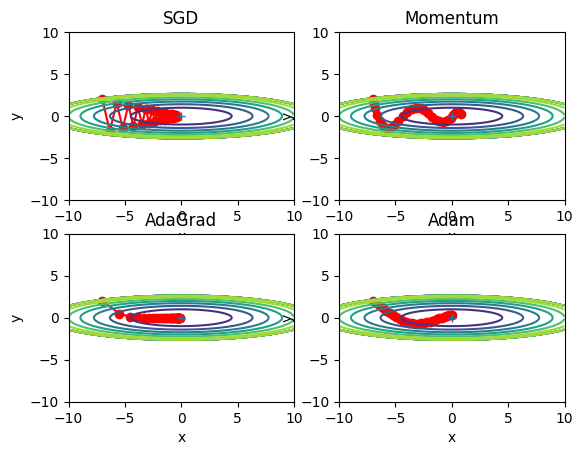

In [6]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    
    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.show()


* 모든 문제에서 항상 뛰어난 기법은 없음

#### MNIST 데이터셋으로 본 갱신 방법 비교

===========iteration:0===========
SGD:2.3351450798442404
Momentum:2.380834690117806
AdaGrad:2.1208036269823753
Adam:2.2119680459077555
===========iteration:100===========
SGD:1.5164161333552522
Momentum:0.29606126568116653
AdaGrad:0.13517150610308418
Adam:0.17026524797504022
===========iteration:200===========
SGD:0.6104386403825598
Momentum:0.15976962296014136
AdaGrad:0.06544685268827533
Adam:0.10482465336161721
===========iteration:300===========
SGD:0.5477599097202518
Momentum:0.2368087960775581
AdaGrad:0.10256944711710922
Adam:0.20767838675255168
===========iteration:400===========
SGD:0.488132657462283
Momentum:0.1907500792681094
AdaGrad:0.11087936051114206
Adam:0.13482506873416272
===========iteration:500===========
SGD:0.45232698258076065
Momentum:0.24345222185351018
AdaGrad:0.0863950400600121
Adam:0.12372455993958123
===========iteration:600===========
SGD:0.3075092570651887
Momentum:0.12151265510553047
AdaGrad:0.054944861347253335
Adam:0.09094967719677435
===========iteration:

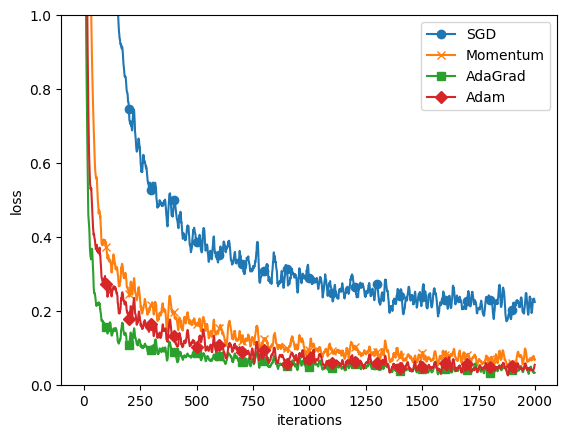

In [8]:
import os
import sys
sys.path.append(os.pardir)
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

### 가중치의 초깃값
* 신경망 학습에서 특히 중요한 것이 가중치의 초깃값
* 이에 따라 학습의 성패가 갈리기도 함

#### 초깃값을 0으로 하면?
* 가중치 감소는 오버피팅을 억제해 범용 성능을 높임
* 가중치를 작게 만들려면 초깃값도 최대한 작은 값이 정석
* 그러나 가중치 초깃값을 모두 0으로 하면 학습이 올바로 이뤄지지 않음  
-> 오차역전파법에서 모든 가중치의 값이 똑같이 갱신되기 때문  
=> 초깃값을 무작위로 설정해야 함

#### 은닉층의 활성화값 분포
* 각 층의 활성화값은 적당히 고루 분포되어야 함
* 층과 층 사이에 적당하게 다양한 데이터가 흐르게 해야 신경망 학습이 효율적을 이뤄지기 때문
* 활성화값들이 치우치면 표현력을 제한한다는 관점에서 문제가 됨
* 치우친 데이터가 흐르면 기울기 소실이나 표현력 제한 문제에 빠져 학습이 잘 이뤄지지 않음

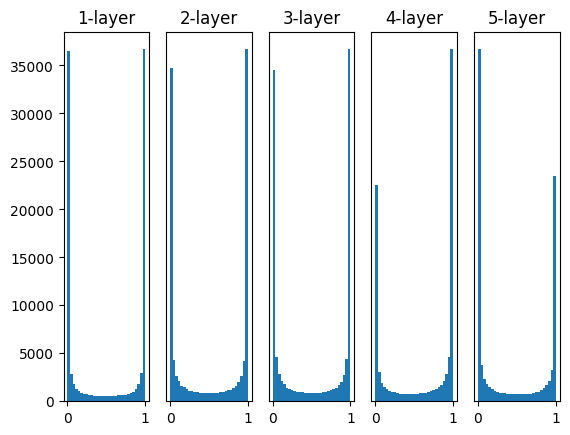

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)
    
input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 초깃값을 다양하게 바꿔가며 실험해보자！
    w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)


    # 활성화 함수도 바꿔가며 실험해보자！
    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()


* 각 층의 활성화값들이 0과 1에 치우쳐 분포
* 시그모이드는 출력이 0에 가까워지자 미분은 0에 다가감
* 데이터가 0과 1에 치우쳐 분포하게 되면 역전파 기울기 값이 점점 작아지다가 사라짐  
=> 기울기 소실

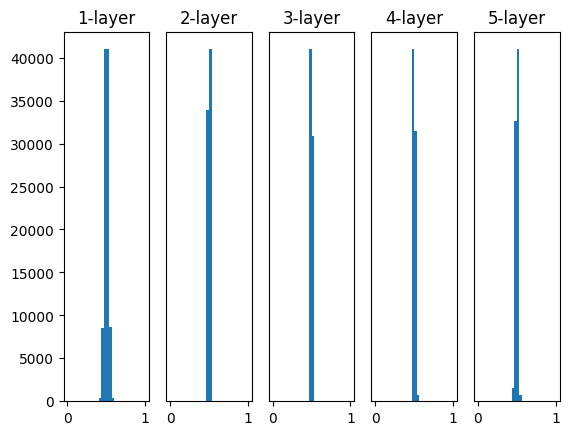

In [10]:
input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 초깃값을 다양하게 바꿔가며 실험해보자！
    w = np.random.randn(node_num, node_num) * 0.01

    a = np.dot(x, w)


    # 활성화 함수도 바꿔가며 실험해보자！
    z = sigmoid(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

* 기울기 소실 문제는 일어나지 않음
* 예를 드러 뉴런 100개가 거의 같은 값을 출력한다면 뉴런 1개와 별반 다를 바 없음

##### Xavier 초깃값
* 일반적인 딥러닝 프레임워크들이 표준적으로 이용
* 앞 계층의 노드가 n개라면 표준편차가 $\frac{1}{\sqrt n}$ 인 분포를 사용하면 됨
* 앞 층에 노드가 많을수록 대상 노드의 초깃값으로 설정하는 가중치가 좁게 퍼짐

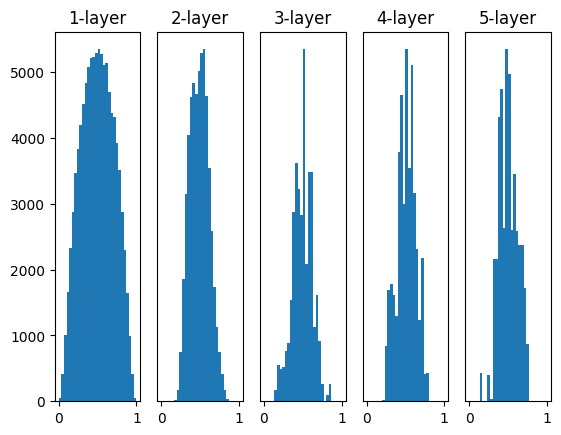

In [9]:
input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 초깃값을 다양하게 바꿔가며 실험해보자！
    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)


    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

* 오른쪽으로 갈수록 일그러짐 -> sigmoid 대신 tanh 함수를 사용하면 개선 가능

#### ReLU를 사용할 때의 가중치 초깃값
* Xavier 초깃값은 활성화 함수가 선형인 것을 전제
* ReLU는 ReLU에 특화된 초깃값을 이용할 것을 권장  
=> He 초깃값

##### He 초깃값
* 앞 계층의 노드가 n개일 때 표준편차가 $\sqrt{\frac{2}{n}}$ 인 정규분포를 사용  
=> ReLU는 음의 영역이 0이라서 더 넓게 분포시키기 위해 2배의 계수가 필요하다고 해석 가능

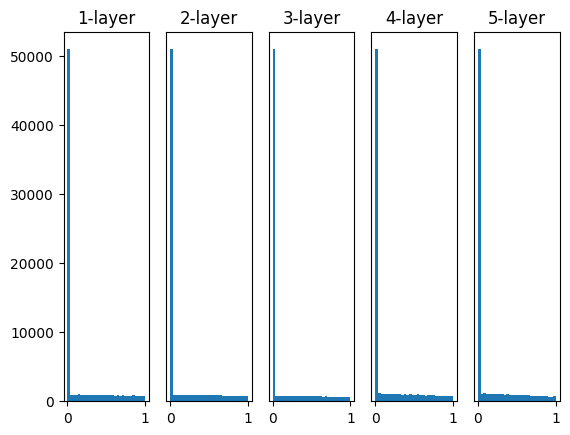

In [8]:
input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w)

    z = ReLU(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

* 모든 층에서 균일하게 분포  
=> 활성화로 ReLU를 사용할 때는 He 초깃값을, sigmoid나 tanh 등의 S자 모양 곡선일 때는 Xavier 초깃값을 사용하는 것이 모범 사례

#### MNIST 데이터셋으로 본 가중치 초깃값 비교

===========iteration:0===========
std=0.01:2.3024996892870497
Xavier:2.2788398667625454
He:2.3676874379757304
===========iteration:100===========
std=0.01:2.3015673370044714
Xavier:2.2399288680397236
He:1.6102710640612297
===========iteration:200===========
std=0.01:2.302315159439301
Xavier:2.121761050981476
He:0.8322104741794334
===========iteration:300===========
std=0.01:2.3001326743205057
Xavier:1.7314804911285369
He:0.45270484827488067
===========iteration:400===========
std=0.01:2.3038788958597394
Xavier:1.3575883571011143
He:0.5037467662399235
===========iteration:500===========
std=0.01:2.2997080549054196
Xavier:0.856627812055438
He:0.3941677685568271
===========iteration:600===========
std=0.01:2.299760876367757
Xavier:0.6289616871762203
He:0.27631029080760794
===========iteration:700===========
std=0.01:2.3049718915850006
Xavier:0.5956913630734613
He:0.38393597585061445
===========iteration:800===========
std=0.01:2.3030107381827025
Xavier:0.533967833580415
He:0.3661332842781

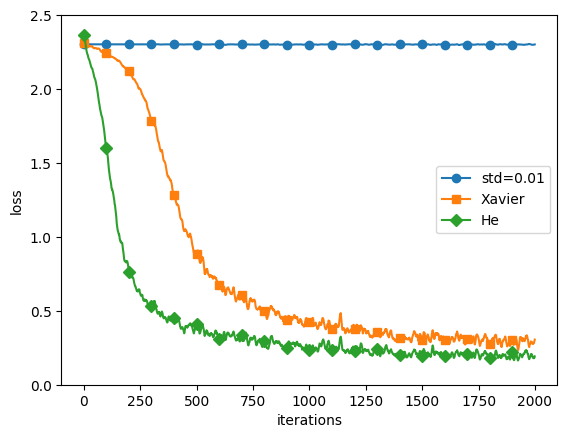

In [12]:
import os
import sys

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()


* 층별 뉴런 수가 100개인 5층 신경망에서 활성화 함수로 ReLU 사용
* std = 0.01일 때는 학습이 전혀 이루어지지 않음
* 나머지는 학습이 잘 이루어짐, 학습 진도는 He 초깃값 쪽이 더 빠름
=> 초깃값은 신경망 학습에 아주 중요한 포인트

### 배치 정규화

#### 배치 정규화 알고리즘
* 장점
    * 학습을 빨리 진행할 수 있음(학습 속도 개선)
    * 초깃값에 크게 의존하지 않음
    * 오버피팅을 억제(드롭아웃 등의 필요성 감소)
* 각 층에서의 활성화 값이 적당히 분포되도록 조정하는 것

* 배치 정규화는 학습 시 미니배치를 단위로 정규화
    * 구체적으로 데이터 분포가 평균이 0, 분산이 1이 되도록 정규화
$$
\mu_B \gets \frac{1}{m} \sum_{i=1}^{m} x_i
$$
$$
\sigma_B^2 \gets \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2
$$
$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$
* 여기에는 미니배치 $B = \{x_1, x_2, ..., x_m\}$ 이라는 m개의 입력 데이터의 집합에 대해 $\mu_B$ 와 분산 $\sigma^2_B$ 을 구함
* 그리고 입력 데이터를 평균이 0, 분산이 1이 되게 정규화
* $\epsilon$: 작은 값으로 0으로 나누는 사태를 예방하는 역할

* 위 식은 단순히 미니배치 입력 데이터를 평균 0, 분산 1인 데이터 $\{\hat x_1, \hat x_2, ...,\hat x_m\}$ 으로 변환
* 이 처리를 활성화 함수의 앞 혹은 뒤에 삽입함으로써 데이터 분포가 덜 치우치게 할 수 있음
* 또한 배치 정규화 계층마다 정규화된 데이터에 고유한 확대와 이동 변환을 수행
$$
y_i \gets \hat{x}_i + \beta
$$
* $\gamma$ 가 확대를, $\beta$ 가 이동을 담당
* 처음에는 $\gamma = 1$, $\beta = 0$ 부터 시작하고 학습하면서 적합한 값으로 조정

#### 배치 정규화의 효과

============== 1/16 ==============
epoch:0 | 0.094 - 0.137


c:\Users\기현\Desktop\cs\deep_learning\deep_learning_from_scratch_1\..\common\layers.py:62: RuntimeWarning: overflow encountered in dot
  dx = np.dot(dout, self.W.T)
c:\Users\기현\Desktop\cs\deep_learning\deep_learning_from_scratch_1\..\common\layers.py:57: RuntimeWarning: overflow encountered in dot
  out = np.dot(self.x, self.W) + self.b
c:\Users\기현\Desktop\cs\deep_learning\deep_learning_from_scratch_1\..\common\multi_layer_net_extend.py:104: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\Users\기현\Desktop\cs\deep_learning\deep_learning_from_scratch_1\..\common\multi_layer_net_extend.py:104: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\Users\기현\Desktop\cs\deep_learning\deep_learning_from_scratch_1\..\common\functions.py:34: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


epoch:1 | 0.097 - 0.139
epoch:2 | 0.097 - 0.143
epoch:3 | 0.097 - 0.148
epoch:4 | 0.097 - 0.168
epoch:5 | 0.097 - 0.179
epoch:6 | 0.097 - 0.192
epoch:7 | 0.097 - 0.22
epoch:8 | 0.097 - 0.236
epoch:9 | 0.097 - 0.258
epoch:10 | 0.097 - 0.28
epoch:11 | 0.097 - 0.284
epoch:12 | 0.097 - 0.309
epoch:13 | 0.097 - 0.332
epoch:14 | 0.097 - 0.333
epoch:15 | 0.097 - 0.346
epoch:16 | 0.097 - 0.356
epoch:17 | 0.097 - 0.368
epoch:18 | 0.097 - 0.389
epoch:19 | 0.097 - 0.394
============== 2/16 ==============


C:\Users\기현\AppData\Local\Temp\ipykernel_7400\997664152.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


epoch:0 | 0.117 - 0.093
epoch:1 | 0.097 - 0.096
epoch:2 | 0.097 - 0.102
epoch:3 | 0.097 - 0.115
epoch:4 | 0.097 - 0.144
epoch:5 | 0.097 - 0.165
epoch:6 | 0.097 - 0.183
epoch:7 | 0.097 - 0.207
epoch:8 | 0.097 - 0.229
epoch:9 | 0.097 - 0.258
epoch:10 | 0.097 - 0.273
epoch:11 | 0.097 - 0.302
epoch:12 | 0.097 - 0.334
epoch:13 | 0.097 - 0.348
epoch:14 | 0.097 - 0.374
epoch:15 | 0.097 - 0.398
epoch:16 | 0.097 - 0.412
epoch:17 | 0.097 - 0.427
epoch:18 | 0.097 - 0.443
epoch:19 | 0.097 - 0.461
============== 3/16 ==============
epoch:0 | 0.084 - 0.109
epoch:1 | 0.375 - 0.109
epoch:2 | 0.529 - 0.146
epoch:3 | 0.663 - 0.185
epoch:4 | 0.713 - 0.228
epoch:5 | 0.762 - 0.283
epoch:6 | 0.819 - 0.304
epoch:7 | 0.861 - 0.346
epoch:8 | 0.878 - 0.383
epoch:9 | 0.896 - 0.42
epoch:10 | 0.927 - 0.438
epoch:11 | 0.937 - 0.466
epoch:12 | 0.951 - 0.493
epoch:13 | 0.96 - 0.516
epoch:14 | 0.97 - 0.534
epoch:15 | 0.981 - 0.556
epoch:16 | 0.988 - 0.58
epoch:17 | 0.99 - 0.593
epoch:18 | 0.991 - 0.609
epoch:19 | 0.99

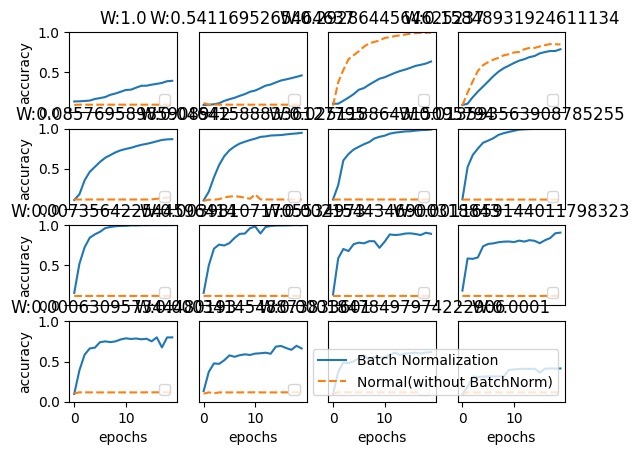

In [13]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.show()


### 바른 학습을 위해

* 기계학습에서는 오버피팅이 문제가 되는 일이 많음
* 오버피팅: 신경망이 훈련 데이터에만 지나치게 적응되어 그 외 데이터에는 제대로 적응하지 못하는 상태를 말함
=> 오버피팅을 억제하는 기술이 중요함

#### 오버피팅
* 오버피팅은 주로 다음의 두 경우에 일어남
    * 매개변수가 많고 표현력이 높은 모델
    * 훈련 데이터가 적음

* 고의로 오버피팅을 일으켜서 확인
    * 60,000개의 MNIST 데이터셋의 훈련 데이터 중 300개만 사용
    * 7층 네트워크를 사용해 네트워크의 복잡성을 높임
    * 각 층의 뉴런은 100개, 활성화 함수는 ReLU를 사용

epoch:0, train acc:0.13, test acc:0.1155
epoch:1, train acc:0.14333333333333334, test acc:0.1237
epoch:2, train acc:0.15, test acc:0.1376
epoch:3, train acc:0.17333333333333334, test acc:0.1459
epoch:4, train acc:0.18, test acc:0.1529
epoch:5, train acc:0.19333333333333333, test acc:0.1579
epoch:6, train acc:0.19333333333333333, test acc:0.1651
epoch:7, train acc:0.19333333333333333, test acc:0.1677
epoch:8, train acc:0.19333333333333333, test acc:0.1707
epoch:9, train acc:0.19333333333333333, test acc:0.1691
epoch:10, train acc:0.19666666666666666, test acc:0.1708
epoch:11, train acc:0.2, test acc:0.1723
epoch:12, train acc:0.20333333333333334, test acc:0.1781
epoch:13, train acc:0.21, test acc:0.1827
epoch:14, train acc:0.22, test acc:0.1858
epoch:15, train acc:0.22666666666666666, test acc:0.1873
epoch:16, train acc:0.22333333333333333, test acc:0.1894
epoch:17, train acc:0.22333333333333333, test acc:0.1933
epoch:18, train acc:0.23333333333333334, test acc:0.1992
epoch:19, train ac

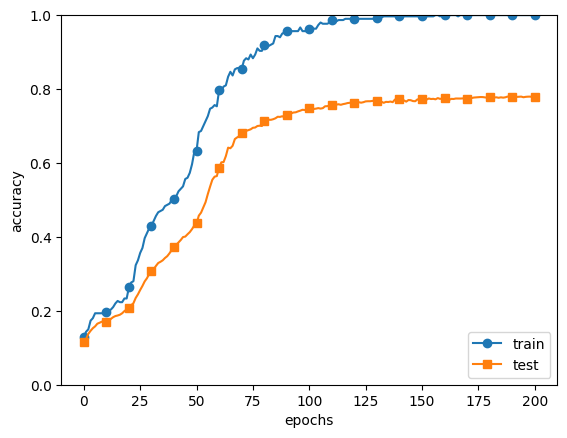

In [15]:
import os
import sys

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


#### 가중치 감소
* 오버피팅 억제용으로 가중치 감소가 있음
* 학습 과정에서 큰 가중치에 대해서는 그에 상응하는 큰 페널티를 부과해 오버피팅을 억제  
=> 오버피팅은 가중치 매개변수의 값이 커서 발생하는 경우가 많기 때문

* 신경망 학습의 목적은 손실 함수의 값을 줄이는 것
* 예를 들어 가중치의 제곱 법칙(L2 법칙)을 손실 함수에 더함 -> 가중치가 커지는 것을 억제
* 가중치를 $\bold W$ 라 하면 L2 법칙에 따른 가중치 감소는 $\frac{1}{2} \lambda \bold W^2$ 이 되고 이를 손실 함수에 더함
    * 여기서 $\lambda$ 는 정규화의 세기를 조절하는 하이퍼파라미터, 클수록 큰 가중치에 대한 페널티가 커짐
    * $\frac{1}{2}$ 는 미분 결과인 $\lambda \bold W$ 를 조저하는 역할의 상수
* 가중치 기울기를 구하는 계산에서는 그동안의 오차역전파법에 따른 결과에 정규화 항을 미분한 $\lambda \bold W$ 를 더함

* L1 법칙은 절댓값의 합, 즉 $|w_1| + |w_2| + ... + |w_n|$ 에 해당
* L $\infty$ 법칙은 Max 법칙이라고도 하며 각 원소의 절댓값 중 가장 큰 것에 해당

epoch:0, train acc:0.08333333333333333, test acc:0.0991
epoch:1, train acc:0.12666666666666668, test acc:0.1226
epoch:2, train acc:0.16, test acc:0.139
epoch:3, train acc:0.16666666666666666, test acc:0.1452
epoch:4, train acc:0.19666666666666666, test acc:0.1615
epoch:5, train acc:0.23333333333333334, test acc:0.1729
epoch:6, train acc:0.22666666666666666, test acc:0.164
epoch:7, train acc:0.22666666666666666, test acc:0.1665
epoch:8, train acc:0.25, test acc:0.1765
epoch:9, train acc:0.2633333333333333, test acc:0.1859
epoch:10, train acc:0.27666666666666667, test acc:0.1884
epoch:11, train acc:0.28, test acc:0.1905
epoch:12, train acc:0.30666666666666664, test acc:0.2009
epoch:13, train acc:0.31333333333333335, test acc:0.205
epoch:14, train acc:0.3233333333333333, test acc:0.2171
epoch:15, train acc:0.3566666666666667, test acc:0.2373
epoch:16, train acc:0.36666666666666664, test acc:0.2518
epoch:17, train acc:0.38333333333333336, test acc:0.2699
epoch:18, train acc:0.4166666666666

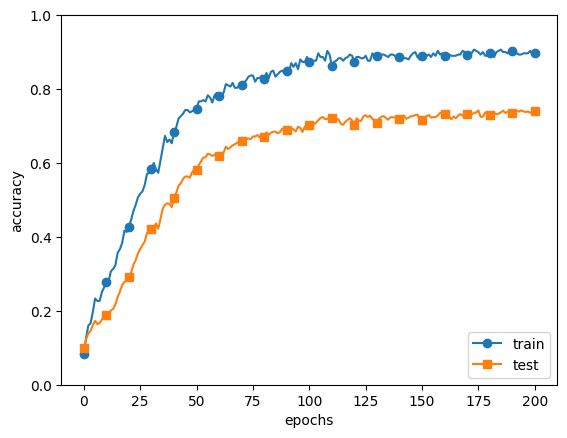

In [16]:
import os
import sys

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


* $\lambda$ = 0.1로 가중치 감소를 적용

#### 드롭아웃
* 신경망 모델이 복잡해지면 가중치 감소만으로는 대응하기 어려워짐 -> 드롭아웃 기법을 이용
* 드롭아웃은 뉴런을 임의로 삭제하면서 학습하는 방법
* 훈련 때 은닉층의 뉴런을 무작위로 골라 삭제, 삭제된 뉴런은 신호를 전달하지 않게 됨
* 훈련 때는 데이터를 흘릴 때마다 삭제할 뉴런을 무작위로 선택하고, 시험 때는 모든 뉴런에 신호를 전달
* 단, 시험 때는 각 뉴런의 출력에 훈련 때 삭제한 비율을 곱하여 출력함

In [17]:
class Dropout:
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask

* 훈련 시에는 순전파 때마다 self.mask에 삭제할 뉴런을 False로 표시
* self.mask는 x와 형상이 같은 배열을 무작위로 생성하고, 그 값이 dropout_ratio보다 큰 원소만 True로 설정
* 역전파 때 동작은 ReLU와 동일

In [18]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from common.optimizer import *

class Trainer:
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='SGD', optimizer_param={'lr':0.01}, 
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # optimzer
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum, 'nesterov':Nesterov,
                                'adagrad':AdaGrad, 'rmsprpo':RMSprop, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0
        
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]
        
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)
        
        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))
        
        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1
            
            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]
                
            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        for i in range(self.max_iter):
            self.train_step()

        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))



train loss:2.32154803320614
=== epoch:1, train acc:0.09666666666666666, test acc:0.0866 ===
train loss:2.3210664957779876
train loss:2.333996180662366
train loss:2.330086534662017
=== epoch:2, train acc:0.09666666666666666, test acc:0.0867 ===
train loss:2.315929810120806
train loss:2.323484244932105
train loss:2.3345112851551435
=== epoch:3, train acc:0.09333333333333334, test acc:0.0881 ===
train loss:2.3181126795614713
train loss:2.345755066793068
train loss:2.2876132007726455
=== epoch:4, train acc:0.1, test acc:0.0873 ===
train loss:2.2942917352387906
train loss:2.3491524019314753
train loss:2.327396684768115
=== epoch:5, train acc:0.09666666666666666, test acc:0.0863 ===
train loss:2.3111901742822023
train loss:2.329125472264419
train loss:2.3359369910768506
=== epoch:6, train acc:0.09, test acc:0.0843 ===
train loss:2.298578751977695
train loss:2.3165474060926816
train loss:2.3407362103839096
=== epoch:7, train acc:0.08666666666666667, test acc:0.084 ===
train loss:2.32961572969

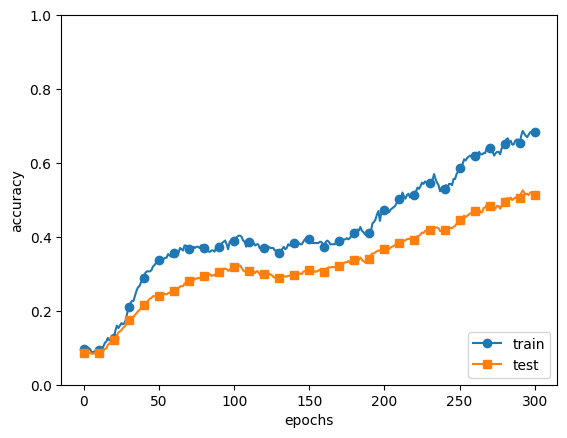

In [19]:
import os
import sys
sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비울 설정 ========================
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


##### 앙상블 학습
* 개별적으로 학습시킨 여러 모델의 출력을 평균 내어 추론하는 방식
* 앙상블은 드롭아웃과 밀접함
* 드롭아웃이 학습 때 뉴런을 무작위로 삭제하는 행위를 매번 다른 모델을 학습시키는 것으로 해석할 수 있음
* 추론 시에는 뉴런의 출력에 삭제한 비율을 곱함으로써 앙상블 학습에서 여러 모델의 평균을 내는 것과 같은 효과를 얻는 것

### 적절한 하이퍼파라미터 값 찾기
* 하이퍼파라미터는 예를 들어 각 층의 뉴런 수, 배치 크기, 매개변수 갱신 시의 학습률과 가중치 감소 등

#### 검증 데이터
* 하이퍼파라미터의 성능을 평가할 때 시험 데이터를 사용해서 안됨  
-> 같은 성능 평가인데 하이퍼파라미터가 대상일 때 시험 데이터를 사용해 하이퍼파라미터를 조정하면 값이 시험 데이터에 오버피팅되기 때문  
=> 하이퍼파라미터 조정 시 하이퍼파라미터 전용 확인 데이터가 필요하며 일반적으로 검증 데이터라고 부름

* 훈련 데이터: 매개변수 학습
* 검증 데이터: 하이퍼파라미터 성능 평가
* 시험 데이터: 신경망의 범용 성능 평가

In [22]:
from common.util import shuffle_dataset

(x_train, t_train), (x_test, t_test) = load_mnist()

# 훈련 데이터를 뒤섞음
x_train, t_train = shuffle_dataset(x_train, t_train)

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)

x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

#### 하이퍼파라미터 최적화
* 최적화의 핵심은 최적값이 존재하는 범위를 조금씩 주려가는 것
* 범위를 조금씩 줄이려면 우선 대략적인 범위를 설정하고 그 범위에서 무작위로 하이퍼파라미터 값을 골라낸 후, 그 값으로 정확도를 평가
    * 최적화에서는 그리드 서치같은 규칙적인 탐색보다 무작위로 샘플링해 탐색하는 편이 더 좋은 결과를 낸다고 알려짐
* 하이퍼파라미터의 범위는 대략적으로 지정하는 것이 효과적
    * 실제로 0.001에서 1000사이($10^{-3} \sim 10^3$)와 같이 10의 계승 단위로 범위를 지정  
    -> 로그 스케일로 지정
* 학습을 위한 에폭을 작게 해 1회 평가에 걸리는 시간을 단축하는 것이 효과적

* 0단계
    * 하이퍼파라미터 값의 범위를 설정
* 1단계
    * 설정된 범위에서 하이퍼파라미터 값을 무작위로 추출
* 2단계
    * 1단계에서 샘플링한 하이퍼파라미터 값을 사용하여 학습하고, 검증 데이터로 정확도를 평가(단, 에폭은 작게 설정)
* 3단계
    * 1단계와 2단계를 특정 횟수(100회 등) 반복하며, 그 정확도의 결과를 보고 하이퍼파라미터의 범위를 좁힘

##### 베이즈 최적화
* 베이즈 정리를 중심으로 한 수학 이론을 구사하여 더 엄밀하고 효율적으로 최적화를 수행

#### 하이퍼파라미터 최적화 구현

val acc:0.11 | lr:5.678139567585585e-06, weight decay:2.9176039621505537e-08
val acc:0.17 | lr:0.0007065097815178322, weight decay:2.8127491533113985e-05
val acc:0.1 | lr:2.7226312308066066e-06, weight decay:1.0631277703994988e-05
val acc:0.03 | lr:5.121492687304345e-06, weight decay:4.7616774622299314e-05
val acc:0.12 | lr:0.000596064995606561, weight decay:2.1436114397088893e-06
val acc:0.03 | lr:2.489523135416068e-06, weight decay:5.357019867314187e-07
val acc:0.14 | lr:1.719696351729965e-05, weight decay:2.3052297339385596e-07
val acc:0.39 | lr:0.0014798335449301627, weight decay:5.86432379896359e-05
val acc:0.17 | lr:1.49276787641756e-06, weight decay:1.988812752496752e-06
val acc:0.07 | lr:1.7239026112090953e-05, weight decay:1.2991109430007564e-07
val acc:0.19 | lr:0.00048404186407987476, weight decay:2.2564519393877558e-06
val acc:0.18 | lr:0.00017971299588524642, weight decay:2.4726206567781567e-06
val acc:0.05 | lr:0.00011966095412412877, weight decay:8.355049280350174e-08
va

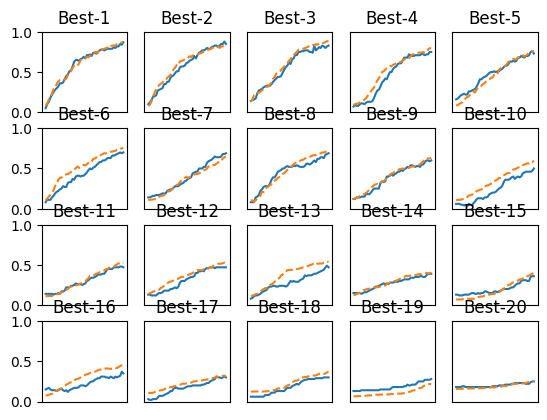

In [23]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# 하이퍼파라미터 무작위 탐색======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 탐색한 하이퍼파라미터의 범위 지정===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# 그래프 그리기========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()
